## Neural Network Project: Image Classification
### 07/08/2024

### CIFAR-100 Image Classification
In this project, we will be working on image classification using the CIFAR-100 dataset. We will explore and compare different transfer learning approaches using the VGG16 model, a convolutional neural network architecture pre-trained on ImageNet.

The sub parts include:

Part 1.1:

*   Feature Extraction:
VGG16 is used as a feature extractor and
a classifier with Dense layers is built on top of the extracted features

*   Fine-tuning:

The upper block of VGG16's convolutional base is fine-tuned and a custom dense layers added for classification while learning rates are adjusted

*   Full Network Training:

All the convolutional blocks of VGG16 are made trainable and
the performances are compared with those of feature extraction and Fine-tuning


Part 1.2: Custom Convolutional Neural Network

In this section, we will create and train a convolutional neural network from scratch by designing a custom architecture, and implementing techniques to enure a good performance








# Part 1: Image classification
## 1.1 Warming up:
### 1. Train classifier on the CIFAR 100 dataset

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading the CIFAR dataset

import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# Preprocess labels
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

# Preprocess input data for VGG16
x_train_vgg = preprocess_input(x_train)
x_test_vgg = preprocess_input(x_test)


169001437/169001437 [==============================] - 5s 0us/step


### Build and train the network on the extracted Features

In this part, we implemented a feature extraction approach using the VGG16 model to classify images from the CIFAR-100 dataset.

The first steps taken before training the model are the Data preparation and preprocessing steps which are:
* Splitting the full training set into training and validation sets (80% training, 20% validation).
* One-hot encoding the labels to prepare them for multi-class classification.
* Preprocessing input data using VGG16's specific preprocessing function to ensure compatibility with the pre-trained model.

### VGG16 Model Setup:

* The VGG16 model pre-trained on ImageNet is loaded, without the top layers.
* The input shape iss set to (32, 32, 3) to match CIFAR-100 image dimensions.

### Feature Extraction:

The preprocessed images are passed through the VGG16 base model to extract features which are extracted for training, validation, and test sets.

### Custom Classifier:

A custom dense network is built on top of the extracted features.
This network is used as the baseline model from which we will adjust in the subsequent models.

* Dense layer with 512 units and ReLU activation
* Dense layer with 256 units and ReLU activation
* Output layer with 100 units (matching CIFAR-100 classes) and softmax activation
* Dropout layer (0.5) for regularization

### Model Compilation and Training:

* The model is compiled using the Adam optimizer and categorical crossentropy loss.
*  Adam optimizer is selected for its adaptive learning rate capabilities, which often leads to faster convergence. It combines the benefits of AdaGrad and RMSProp, which makes it suitable choice for a variety of deep learning tasks, including image classification.

* The categorical crossentropy loss function is ideal for multi-class classification problems with our case CIFAR-100, where each image belongs to exactly one of 100 classes.

* Training is performed for 15 epochs with a batch size of 64, using the extracted features.

The choice of 15 epochs is used because it gives a balance between allowing the model sufficient time to learn and preventing overfitting. It also keeps computational costs reasonable.

The batch size of 64 is used beacuse it balances between computational efficiency and model performance.

### Evaluation:

The model's performance is evaluated on the test set, measuring accuracy and loss.

### Visualization:

Training history is plotted, showing accuracy and loss curves for both training and validation sets.


313/313 [==============================] - 2s 6ms/step
Epoch 1/15
625/625 [==============================] - 6s 4ms/step - loss: 4.5851 - accuracy: 0.1198 - val_loss: 3.1463 - val_accuracy: 0.2316
Epoch 2/15
625/625 [==============================] - 2s 4ms/step - loss: 3.0772 - accuracy: 0.2441 - val_loss: 2.7845 - val_accuracy: 0.2930
Epoch 3/15
625/625 [==============================] - 3s 4ms/step - loss: 2.7950 - accuracy: 0.2947 - val_loss: 2.6447 - val_accuracy: 0.3288
Epoch 4/15
625/625 [==============================] - 3s 5ms/step - loss: 2.6465 - accuracy: 0.3216 - val_loss: 2.5711 - val_accuracy: 0.3421
Epoch 5/15
625/625 [==============================] - 2s 3ms/step - loss: 2.5443 - accuracy: 0.3409 - val_loss: 2.5150 - val_accuracy: 0.3477
Epoch 6/15
625/625 [==============================] - 2s 4ms/step - loss: 2.4596 - accuracy: 0.3585 - val_loss: 2.4904 - val_accuracy: 0.3646
Epoch 7/15
625/625 [==============================] - 2s 3ms/step - loss: 2.3988 - accuracy: 

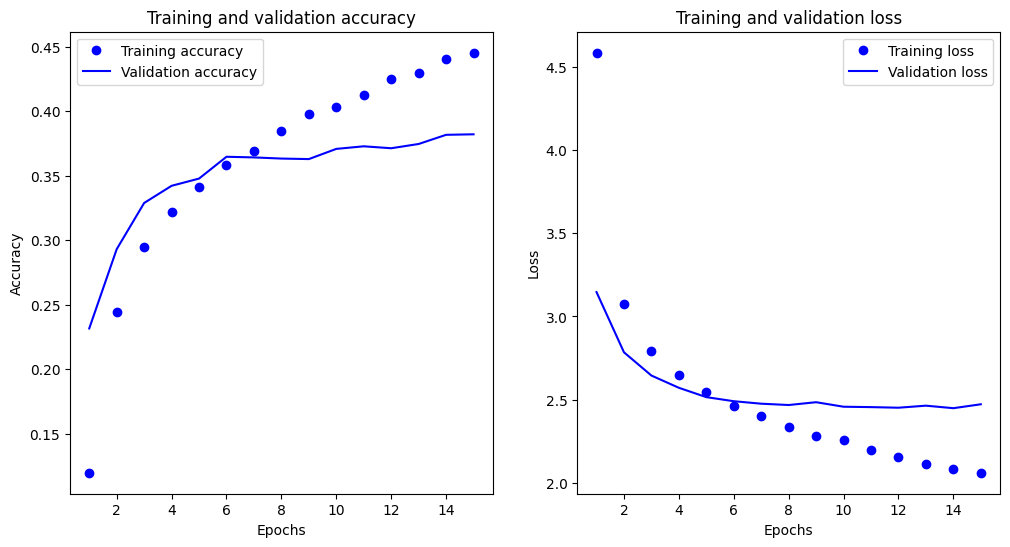

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg16 import preprocess_input, VGG16
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-100 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Split the full training set into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# One-hot encode the labels
y_train = to_categorical(y_train, 100)
y_val = to_categorical(y_val, 100)
y_test = to_categorical(y_test, 100)

# Preprocess the input data for VGG16
x_train_vgg = preprocess_input(x_train)
x_val_vgg = preprocess_input(x_val)
x_test_vgg = preprocess_input(x_test)

# Load VGG16 model without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Extract features using VGG16
train_features = base_model.predict(x_train_vgg)
val_features = base_model.predict(x_val_vgg)
test_features = base_model.predict(x_test_vgg)

# Build and compile the dense model for classification
def build_dense_model(input_shape):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(100, activation='softmax'))  # Softmax activation for multiclass classification
    return model

input_shape = train_features.shape[1:]

model = build_dense_model(input_shape)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with validation data
history = model.fit(train_features, y_train, epochs=15, batch_size=64, validation_data=(val_features, y_val))

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_features, y_test)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

# Plot training history
history_dict = history.history
epochs = range(1, len(history_dict['accuracy']) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Training accuracy')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


### Results:
The baseline model achieved a test accuracy of 0.3829 and a test loss of 2.4765.

The validation accuracy curves show a steady increase with rising epochs up till about 7 epochs where it levels off. This indicates some overfitting is present.

In the same way, the validation loss curves also demonstrate a steady decrease which stops around the 7th epoch which suggests overfitting.

This model will be adjusted in the next iterations to achieve better performance



## First model iteration

### Modified Dense Model for CIFAR-100 Classification using VGG16 Features

In this iteration, we modified the dense model architecture used for classifying the CIFAR-100 images as follows:

The dense Layer Architecture was modified by adding another layer and increasing the number of units in the existing layers.

* First dense layer: 1024 units (increased from 512)
* Second dense layer: 512 units (new addition)
* Third dense layer: 256 units (unchanged)

* The increased model capacity enables more complex feature interactions. The additional layer and increased units provide the model with more parameters to learn complex patterns in the extracted features, which can result to identifying more detailed relationships in the data and hence improved classification performance.

* The dropout layer (0.5 rate) is now placed after the second dense layer instead of the first.
Moving the dropout layer deeper into the network allows the initial layers to learn more robust features. This placement can help in reducing overfitting while still maintaining the model's capacity to learn complex patterns.

* Increased Number of Epochs:
The model is now trained for 30 epochs instead of 15 because doubling the number of epochs gives the more complex model additional time to learn. This extended training period allows the model to potentially find a better optimum, especially with the increased model capacity.

The batch size (64), optimizer (Adam) and loss function (categorical crossentropy) remain the same as in the baseline model.


Epoch 1/30
625/625 [==============================] - 5s 5ms/step - loss: 3.9378 - accuracy: 0.1437 - val_loss: 3.0075 - val_accuracy: 0.2593
Epoch 2/30
625/625 [==============================] - 3s 4ms/step - loss: 3.0619 - accuracy: 0.2503 - val_loss: 2.7576 - val_accuracy: 0.3148
Epoch 3/30
625/625 [==============================] - 2s 4ms/step - loss: 2.7525 - accuracy: 0.3092 - val_loss: 2.6348 - val_accuracy: 0.3360
Epoch 4/30
625/625 [==============================] - 2s 4ms/step - loss: 2.5293 - accuracy: 0.3507 - val_loss: 2.5575 - val_accuracy: 0.3587
Epoch 5/30
625/625 [==============================] - 3s 4ms/step - loss: 2.3594 - accuracy: 0.3869 - val_loss: 2.5501 - val_accuracy: 0.3651
Epoch 6/30
625/625 [==============================] - 3s 5ms/step - loss: 2.2097 - accuracy: 0.4178 - val_loss: 2.5401 - val_accuracy: 0.3701
Epoch 7/30
625/625 [==============================] - 3s 4ms/step - loss: 2.0971 - accuracy: 0.4433 - val_loss: 2.5004 - val_accuracy: 0.3790
Epoch 

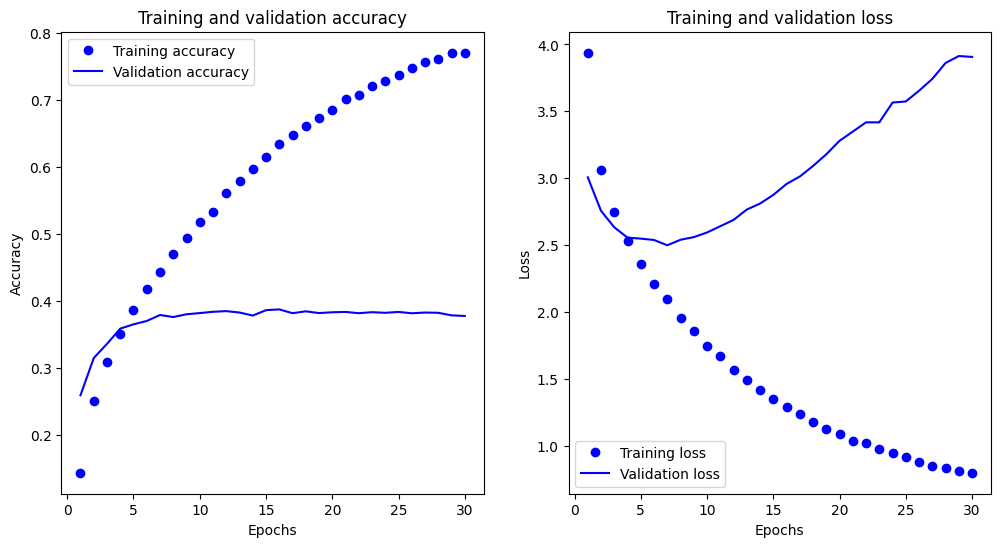

In [ ]:
# Build and compile the dense model for classification
def build_dense_model(input_shape):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(1024, activation='relu'))
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(100, activation='softmax'))  # Softmax activation for multiclass classification
    return model

input_shape = train_features.shape[1:]

model = build_dense_model(input_shape)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with validation data
history = model.fit(train_features, y_train, epochs=30, batch_size=64, validation_data=(val_features, y_val))

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_features, y_test)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

# Plot training history
history_dict = history.history
epochs = range(1, len(history_dict['accuracy']) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Training accuracy')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Results:

The modified model achieved a slightly lower test accuracy of 0.3824 and a higher test loss of 3.87.

The validation accuracy curves show a steady increase with rising epochs just at the start and levels off from the 6th epoch. This indicates an even higher level of overfitting compared to the baseline model.

Also, the validation loss curves demonstrate a small decrease till the 6th epoch where a rise in validation loss is observed.


Although this modified model had an increased complexity which intended to capture more complex relationships, it rather led to overfitting, which may suggest that the model memorized training data rather than learning generalizable patterns. The additional parameters may not have been effectively used.
Furthermore, the increased model size might have required more robust regularization techniques or different hyperparameters to optimize effectively.

Further adjustments will be done in the next iterations


## Second model Iteration

In this iteration, there are some changes to the model architecture and training process which are expected to improve the model's performance. Here are the main changes:

* Addition of Batch Normalization:
Batch Normalization layers were added after each Dense layer.
This helps normalize the inputs to each layer, which can speed up training and provide a regularizing effect which can potentially improve performance.

* Increased Dropout Usage:
Dropout layers (0.5 rate) are now applied after each Dense layer and its corresponding Batch Normalization layer.
This aims to further reduce overfitting by introducing more regularization throughout the network. This can help the model learn more robust features.
* Learning Rate Adjustment:
The Adam optimizer's learning rate is set to 0.001. Specifying the learning rate gives more control over the optimization process. This rate (0.001) is a common starting point that often works well with Adam optimizer.

* Implementation of Early Stopping:
An EarlyStopping callback is added to monitor validation loss with a patience of 5 epochs.
This can help prevent overfitting by stopping training when the model's performance on the validation set stops improving. This can lead to better generalization and save computational resources.

* Restoration of Best Weights:
The early stopping callback is configured to restore the best weights found during training which ensures that the final model uses the weights that performed best on the validation set, not necessarily those from the last epoch.



313/313 [==============================] - 2s 6ms/step
Epoch 1/30
625/625 [==============================] - 11s 8ms/step - loss: 3.6491 - accuracy: 0.1703 - val_loss: 2.5738 - val_accuracy: 0.3323
Epoch 2/30
625/625 [==============================] - 4s 6ms/step - loss: 2.8745 - accuracy: 0.2727 - val_loss: 2.4153 - val_accuracy: 0.3667
Epoch 3/30
625/625 [==============================] - 4s 6ms/step - loss: 2.6649 - accuracy: 0.3140 - val_loss: 2.3475 - val_accuracy: 0.3794
Epoch 4/30
625/625 [==============================] - 3s 5ms/step - loss: 2.5516 - accuracy: 0.3408 - val_loss: 2.2819 - val_accuracy: 0.3926
Epoch 5/30
625/625 [==============================] - 4s 7ms/step - loss: 2.4629 - accuracy: 0.3545 - val_loss: 2.2488 - val_accuracy: 0.4041
Epoch 6/30
625/625 [==============================] - 4s 6ms/step - loss: 2.3963 - accuracy: 0.3712 - val_loss: 2.2299 - val_accuracy: 0.4069
Epoch 7/30
625/625 [==============================] - 4s 6ms/step - loss: 2.3326 - accuracy:

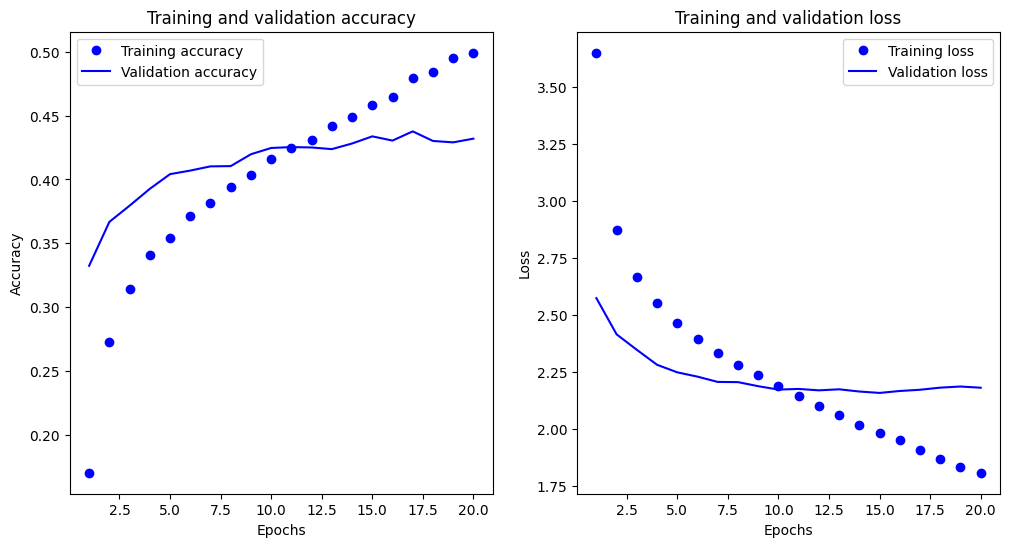

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg16 import preprocess_input, VGG16
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load CIFAR-100 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Split the full training set into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# One-hot encode the labels
y_train = to_categorical(y_train, 100)
y_val = to_categorical(y_val, 100)
y_test = to_categorical(y_test, 100)

# Preprocess the input data for VGG16
x_train_vgg = preprocess_input(x_train)
x_val_vgg = preprocess_input(x_val)
x_test_vgg = preprocess_input(x_test)

# Load VGG16 model without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Extract features using VGG16
train_features = base_model.predict(x_train_vgg)
val_features = base_model.predict(x_val_vgg)
test_features = base_model.predict(x_test_vgg)

# Define the more complex dense model with regularization and batch normalization
def build_complex_model(input_shape):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(1024, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(100, activation='softmax'))
    return model

input_shape = train_features.shape[1:]

model = build_complex_model(input_shape)
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Implement early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with validation data and early stopping
history = model.fit(train_features, y_train, epochs=30, batch_size=64, validation_data=(val_features, y_val), callbacks=[early_stopping])

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_features, y_test)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

# Plot training history
history_dict = history.history
epochs = range(1, len(history_dict['accuracy']) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Training accuracy')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


### Results
The modified model shows an improvement with a higher test accuracy of 0. 4372 and a lower test loss of 2.177.

The validation accuracy curves show a steady increase with rising epochs that levels off around the 10th epoch. There is still a sign of overfitting with this model but it is better than that of the previous model.
The validation loss curves also demonstrate a steady decrease till the 10th epoch where it becomes stable.

This significant improvement indicates that the changes made to the model architecture and training process were effective.

* The higher test accuracy suggests that the model is generalizing better to unseen data which can be attributed to the added regularization techniques (batch normalization and increased dropout) and the use of early stopping.

While this model shows significant improvement, there's still somme room for improvement.

## Third model Iteration


The main adjustment in this iteration compared to the second modified model is:

1. Reduced Number of Training Epochs:
   - The maximum number of epochs has been reduced from 30 to 10 with aim to reduce the overfitting. In the previous model, it was observed that the validation metrics stabilized around the 10th epoch. By setting the maximum epochs to 10, we're trying to prevent potential overfitting that might occur in later epochs.

  With fewer maximum epochs, we are expecting that the training process should complete more quickly.




313/313 [==============================] - 2s 6ms/step
Epoch 1/10
625/625 [==============================] - 7s 7ms/step - loss: 3.6557 - accuracy: 0.1706 - val_loss: 2.5868 - val_accuracy: 0.3307
Epoch 2/10
625/625 [==============================] - 3s 5ms/step - loss: 2.8770 - accuracy: 0.2720 - val_loss: 2.4129 - val_accuracy: 0.3683
Epoch 3/10
625/625 [==============================] - 3s 5ms/step - loss: 2.6741 - accuracy: 0.3099 - val_loss: 2.3180 - val_accuracy: 0.3886
Epoch 4/10
625/625 [==============================] - 3s 6ms/step - loss: 2.5435 - accuracy: 0.3379 - val_loss: 2.2899 - val_accuracy: 0.3892
Epoch 5/10
625/625 [==============================] - 4s 6ms/step - loss: 2.4596 - accuracy: 0.3537 - val_loss: 2.2452 - val_accuracy: 0.4025
Epoch 6/10
625/625 [==============================] - 3s 5ms/step - loss: 2.3946 - accuracy: 0.3715 - val_loss: 2.2253 - val_accuracy: 0.4063
Epoch 7/10
625/625 [==============================] - 3s 6ms/step - loss: 2.3336 - accuracy: 

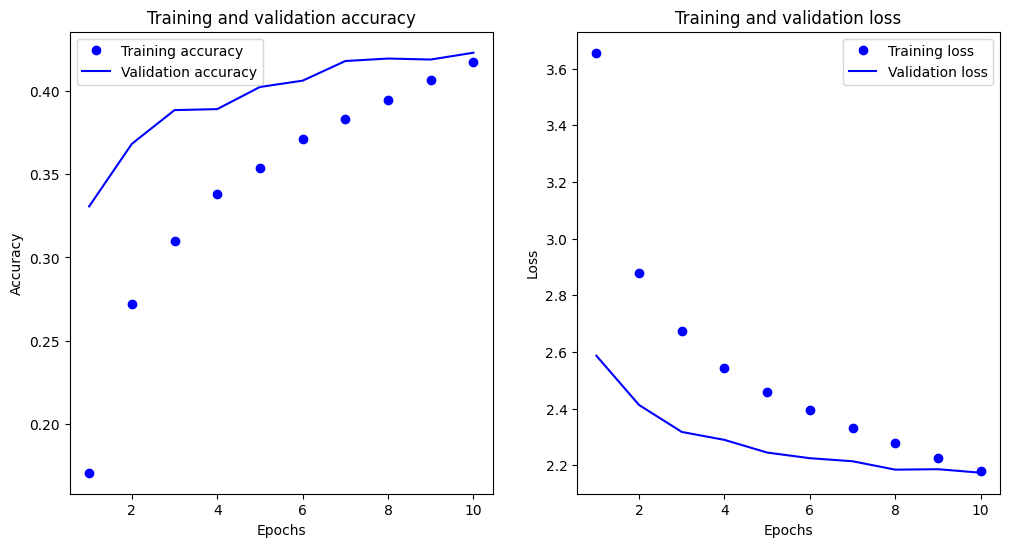

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg16 import preprocess_input, VGG16
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load CIFAR-100 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Split the full training set into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# One-hot encode the labels
y_train = to_categorical(y_train, 100)
y_val = to_categorical(y_val, 100)
y_test = to_categorical(y_test, 100)

# Preprocess the input data for VGG16
x_train_vgg = preprocess_input(x_train)
x_val_vgg = preprocess_input(x_val)
x_test_vgg = preprocess_input(x_test)

# Load VGG16 model without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Extract features using VGG16
train_features = base_model.predict(x_train_vgg)
val_features = base_model.predict(x_val_vgg)
test_features = base_model.predict(x_test_vgg)

# Define the more complex dense model with regularization and batch normalization
def build_complex_model(input_shape):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(1024, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(100, activation='softmax'))
    return model

input_shape = train_features.shape[1:]

model = build_complex_model(input_shape)
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Implement early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with validation data and early stopping
history = model.fit(train_features, y_train, epochs=10, batch_size=64, validation_data=(val_features, y_val), callbacks=[early_stopping])

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_features, y_test)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

# Plot training history
history_dict = history.history
epochs = range(1, len(history_dict['accuracy']) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Training accuracy')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


### Results

This modified model achieved a similar test accuracy of 0.4260 (the previous model had 0.437) and a test loss of 2.188 which almost the same as the values of the previous model.

The validation accuracy curves show a steady increase with rising epochs in the same direction as the training curve with significant reduction in the overfitting.

The validation loss curves also demonstrate a steady decrease all through the epochs. The overfitting is quite less compaared with the previous model.

In conclusion, with this third iteration, we observe a successful refinement of the model training process.
By achieving similar results with fewer epochs, this model demonstrates more efficient training with reduced overfitting. It reaches a comparable performance in less time and with fewer computational resources.



## Question 2: Fine tune the upper block of the Vgg16

Fine-tuning the Upper Block of VGG16 for CIFAR-100 Classification

The data preparation and pre processing steps remain the same. The steps in achieving this are as follows:

1. VGG16 Model Setup:
   - VGG16 is loaded without the top layers, using ImageNet weights.
   - Input shape is set to (32, 32, 3) to match CIFAR-100 image dimensions

2. Layer Freezing:
   - All layers except the last 4 are frozen (non-trainable).
   - Unfreeze the top four layers (upper block) and are set to trainable.
This approach fine-tunes only the upper layers, which helps adapt the model to the new task while retaining lower-level features learned from ImageNet.

3. Custom Top Layers:
   - Dense layers (1024, 512, 256 units) with ReLU activation are added.
   - BatchNormalization and Dropout (0.5) are applied after each Dense layer.
   - Final Dense layer with 100 units and softmax activation for classification.

4. Model Compilation:
   - RMSprop optimizer is used with a low learning rate (1e-5) is suitable for fine-tuning pre-trained models.
   - Categorical crossentropy loss is used for multi-class classification.

5. Training the model:
   - Early stopping is implemented to prevent overfitting.
   - The model is trained for up to 30 epochs with a batch size of 64.

6. Evaluation and Visualization:
   - The model is evaluated on the test set.
   - Training history is plotted to visualize accuracy and loss curves.



Epoch 1/30
625/625 [==============================] - 17s 23ms/step - loss: 5.7628 - accuracy: 0.0134 - val_loss: 4.4703 - val_accuracy: 0.0432
Epoch 2/30
625/625 [==============================] - 13s 21ms/step - loss: 5.3878 - accuracy: 0.0227 - val_loss: 4.1580 - val_accuracy: 0.1034
Epoch 3/30
625/625 [==============================] - 14s 22ms/step - loss: 5.0621 - accuracy: 0.0384 - val_loss: 3.8803 - val_accuracy: 0.1542
Epoch 4/30
625/625 [==============================] - 13s 21ms/step - loss: 4.7653 - accuracy: 0.0573 - val_loss: 3.6737 - val_accuracy: 0.1881
Epoch 5/30
625/625 [==============================] - 13s 21ms/step - loss: 4.5108 - accuracy: 0.0766 - val_loss: 3.4989 - val_accuracy: 0.2169
Epoch 6/30
625/625 [==============================] - 14s 22ms/step - loss: 4.3031 - accuracy: 0.0968 - val_loss: 3.3344 - val_accuracy: 0.2422
Epoch 7/30
625/625 [==============================] - 13s 20ms/step - loss: 4.1266 - accuracy: 0.1160 - val_loss: 3.1959 - val_accuracy:

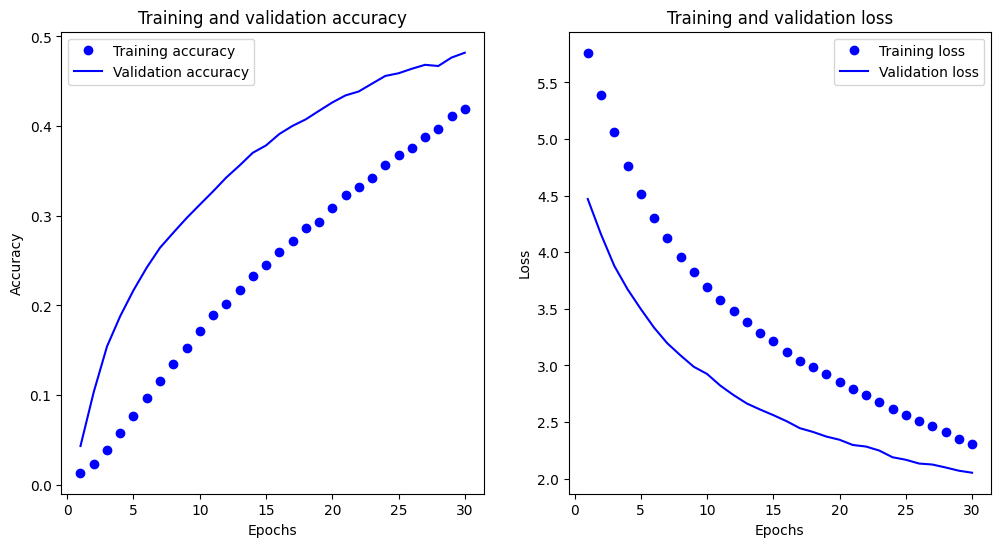

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.applications.vgg16 import preprocess_input, VGG16
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

# Load CIFAR-100 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Split the full training set into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# One-hot encode the labels
y_train = to_categorical(y_train, 100)
y_val = to_categorical(y_val, 100)
y_test = to_categorical(y_test, 100)

# Preprocess the input data for VGG16
x_train_vgg = preprocess_input(x_train)
x_val_vgg = preprocess_input(x_val)
x_test_vgg = preprocess_input(x_test)

# Load VGG16 model without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Freeze the lower layers
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Unfreeze the top layers (upper block)
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Add the dense classification layers on top of the base model
model = Sequential([
    base_model,
    Flatten(),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

# Compile the model with a lower learning rate for RMSprop
model.compile(optimizer=RMSprop(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Implement early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with validation data and early stopping
history = model.fit(x_train_vgg, y_train, epochs=30, batch_size=64, validation_data=(x_val_vgg, y_val), callbacks=[early_stopping])

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test_vgg, y_test)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

# Plot training history
history_dict = history.history
epochs = range(1, len(history_dict['accuracy']) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Training accuracy')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


### Results
The fine-tuned model achieved a higher test accuracy of 0. 4831 and a test loss of 2.042 which shows an improvement from the models that used feature extraction.

The validation accuracy curves show a steady increase with rising epochs in the same direction as the training curve and little or no signs of overfitting can be observed here.

The validation loss curves also demonstrate a steady decrease all through the epochs and some overfitting is observed, as there is some gap between the training and validation plots.

This model performs well enough but in the next models, we will include data augmentation and compare the results.

## Fine-tuned model with Data augmentation

The main difference in this iteration compared to the previous fine-tuned model is the introduction of data augmentation.

1. Data Augmentation Implementation:
   - An ImageDataGenerator is used to apply real-time data augmentation during training.
   - Augmentation techniques applied:
*   Width shift range: 0.1
*   Height shift range: 0.1
*   Horizontal flip: True

  * The data augmentation artificially expands the training dataset by creating modified versions of the existing images. This helps the model learn more robust features and generalize better to unseen data.
  * By introducing variations in the training data, the model is less likely to memorize specific image details, thus reducing overfitting.
   
- This model is expected to perform better on unseen data due to learning from a more diverse set of training examples.
- With augmented data, the model might benefit from training for more epochs before overfitting occurs.



Epoch 1/30
625/625 [==============================] - 37s 53ms/step - loss: 5.7791 - accuracy: 0.0127 - val_loss: 4.4964 - val_accuracy: 0.0420
Epoch 2/30
625/625 [==============================] - 33s 52ms/step - loss: 5.4438 - accuracy: 0.0213 - val_loss: 4.1197 - val_accuracy: 0.0964
Epoch 3/30
625/625 [==============================] - 34s 54ms/step - loss: 5.1195 - accuracy: 0.0342 - val_loss: 3.8511 - val_accuracy: 0.1450
Epoch 4/30
625/625 [==============================] - 33s 52ms/step - loss: 4.8364 - accuracy: 0.0512 - val_loss: 3.6322 - val_accuracy: 0.1918
Epoch 5/30
625/625 [==============================] - 34s 54ms/step - loss: 4.6052 - accuracy: 0.0697 - val_loss: 3.4732 - val_accuracy: 0.2163
Epoch 6/30
625/625 [==============================] - 33s 53ms/step - loss: 4.4095 - accuracy: 0.0864 - val_loss: 3.3224 - val_accuracy: 0.2378
Epoch 7/30
625/625 [==============================] - 34s 54ms/step - loss: 4.2310 - accuracy: 0.1041 - val_loss: 3.1770 - val_accuracy:

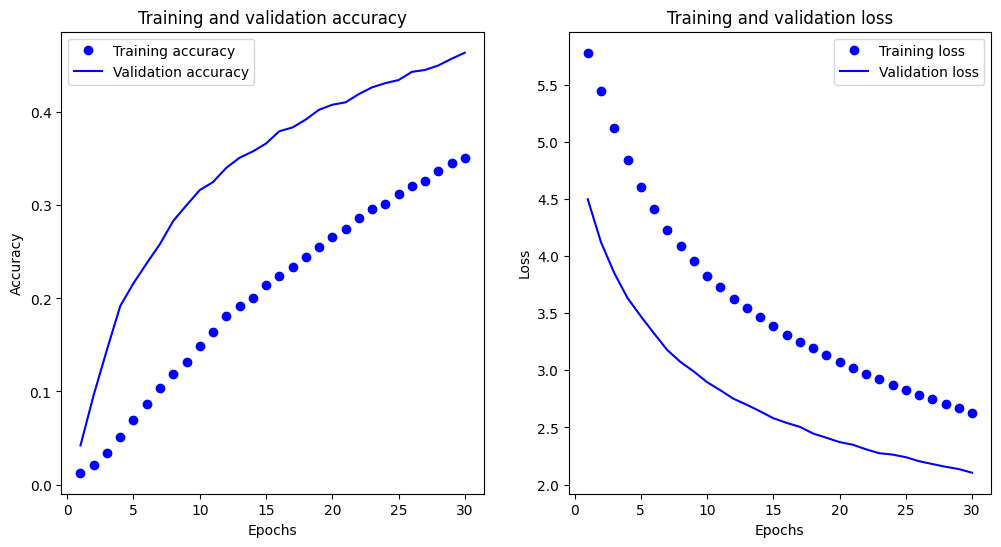

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.applications.vgg16 import preprocess_input, VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-100 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Split the full training set into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# One-hot encode the labels
y_train = to_categorical(y_train, 100)
y_val = to_categorical(y_val, 100)
y_test = to_categorical(y_test, 100)

# Preprocess the input data for VGG16
x_train_vgg = preprocess_input(x_train)
x_val_vgg = preprocess_input(x_val)
x_test_vgg = preprocess_input(x_test)

# Load VGG16 model without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Freeze the lower layers
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Unfreeze the top layers (upper block)
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Add the dense classification layers on top of the base model
model = Sequential([
    base_model,
    Flatten(),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

# Compile the model with a lower learning rate for RMSprop
model.compile(optimizer=RMSprop(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Implement early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Use data augmentation
datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train_vgg)

# Train the model with validation data, early stopping, and data augmentation
history = model.fit(datagen.flow(x_train_vgg, y_train, batch_size=64),
                    epochs=30, validation_data=(x_val_vgg, y_val), callbacks=[early_stopping])

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test_vgg, y_test)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

# Plot training history
history_dict = history.history
epochs = range(1, len(history_dict['accuracy']) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Training accuracy')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()



### Results
This fine-tuned model with data augmentation achieved a test accuracy of 0.467 and a test loss of 2.097 which shows an slight drop from the previous model without the data augmentation.

The validation accuracy curves show a steady increase with rising epochs in the same direction as the training curve and little but slighltly more overfitting can be seen commpared to the previous model.

The validation loss curves also demonstrate a steady decrease all through the epochs and similar level of overfitting as in the previous model.The curves are quite similar to the previous curves.

With this model, the data augmentation introduces more variability in the training data, which can initially lead to a small decrease in performance.This is because the model is learning from a more diverse and challenging dataset, which can result in slightly lower accuracy on a fixed test set. All this could account for the slight drop in performance.

The model will be adjusted more to get an improved performance

## Modified Data augmentation model


Modified Fine-tuned VGG16 Model with Enhanced Data Augmentation for CIFAR-100 Classification

The adjustments in this model are:

1. Modified Dense Layers Architecture:
   - Reduced the number of dense layers from three to two (512 and 256 unit layers).
   Here, fewer parameters can lead to faster training and may be sufficient given the enhanced data augmentation.

2. Removal of Dropout Layers:
   - The dropout layers after the dense layers have been removed.
  With enhanced data augmentation, the model might not need as much regularization through dropout.
   
3. Enhanced Data Augmentation:
   - Added rotation_range=25: Allows images to be rotated up to 25 degrees.
   - Added shear_range=0.1: Applies shear transformation.
   - Added zoom_range=0.1: Allows random zooming.
   - Added fill_mode='nearest': Specifies how to fill in newly created pixels which is a common choice that maintains image integrity during transformations

   These additional augmentations create more diverse training samples, potentially improving the model's ability to generalize.
   The Rotation and Shear range help the model learn invariance to these transformations, which can be present in real-world scenarios.
  

The enhanced data augmentation should help the model learn more robust features and the fewer dense layers could result in quicker training times per epoch all leading to potential model performance.


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.0400 - loss: 4.7814 - val_accuracy: 0.1841 - val_loss: 3.6572
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.1948 - loss: 3.5687 - val_accuracy: 0.2837 - val_loss: 3.0557
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.2812 - loss: 3.0896 - val_accuracy: 0.3347 - val_loss: 2.7676
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.3337 - loss: 2.8086 - val_accuracy: 0.3747 - val_loss: 2.5740
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.3684 - loss: 2.6178 - val_accuracy: 0.3929 - val_loss: 2.4493
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.4002 - loss: 2.4656 - val_accuracy: 0.4172 - val_loss: 2.3513
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.4162 - loss: 2.3748 - val_accuracy: 0.4334 - val_loss: 2.2763
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.4381 - loss: 2.2569 - val_accurac

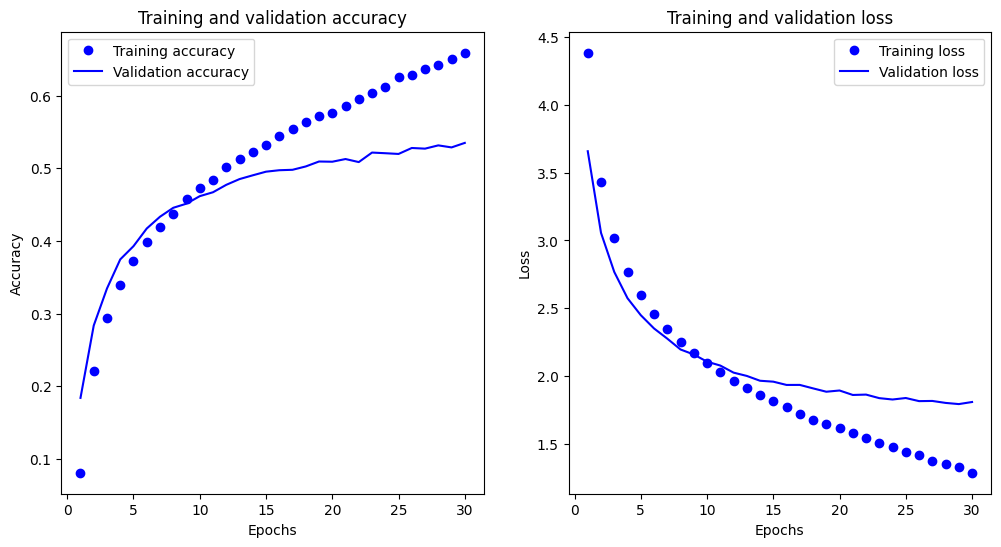

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg16 import preprocess_input, VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-100 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Split the full training set into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# One-hot encode the labels
y_train = to_categorical(y_train, 100)
y_val = to_categorical(y_val, 100)
y_test = to_categorical(y_test, 100)

# Preprocess the input data for VGG16
x_train_vgg = preprocess_input(x_train)
x_val_vgg = preprocess_input(x_val)
x_test_vgg = preprocess_input(x_test)

# Load VGG16 model without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Freeze the lower layers
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Unfreeze the top layers (upper block)
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Add the dense classification layers on top of the base model
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    #Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    #Dropout(0.5),
    Dense(100, activation='softmax')
])

# Compile the model with a lower learning rate for RMSprop
model.compile(optimizer=RMSprop(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Implement early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(x_train_vgg)

# Train the model with validation data, early stopping, and data augmentation
history = model.fit(datagen.flow(x_train_vgg, y_train, batch_size=64),
                    epochs=30, validation_data=(x_val_vgg, y_val), callbacks=[early_stopping])

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test_vgg, y_test)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

# Plot training history
history_dict = history.history
epochs = range(1, len(history_dict['accuracy']) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Training accuracy')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Results

This modified data augmentation model achieved a higher test accuracy of 0.537 and a test loss of 1.792 which shows an increase from the previous data augmentated model.

The validation accuracy curves show a steady increase with rising epochs till the 12th epoch where it remains constant indicating some overfitting present.

The validation loss curves also demonstrate a steady decrease which levels off around the 12th epoch.

This modified data augmentation model shows significant improvement over the previous iterations. The higher test accuracy and lower loss indicate better generalization and overall performance.


### Is data augmentation useful for the model?

Benefits of data augmentation to the model

1. Improved Performance:
   - Without data augmentation: the accuracy was 0.483 (48.3%)
   - With data augmentation: the accuracy is 0.537 (53.7%)
   - This represents an improvement of 5.4 percentage points, or about an 11% relative increase in accuracy.
    
 This percent increase is substantial in our CIFAR-100 classification and the improvement suggests that data augmentation is helping the model generalize better to unseen data.

2. Reduces overfitting:
   - Data augmentation also reduces overfitting by artificially expanding the training set, hence the model is less likely to memorize specific training examples.
   - Improves generalization: The model learns to be more robust to variations in the input data.

In conclusion:
Yes, it absolutely makes sense to use data augmentation for this model. The significant improvement in accuracy demonstrates that data augmentation is effectively helping the model learn more robust and generalizable features from the CIFAR-100 dataset.



### Question 3 of part 1: Train full network

Training the Full VGG16 Network for CIFAR-100 Classification

In this model:
 - All layers of the VGG16 base model are set to trainable.
This allows the entire network to be fine-tuned, potentially learning more task-specific features at all levels of the network.

Custom Top Layers:
   - Dense layers (512, 256 units) with ReLU activation are added.
   - BatchNormalization is applied after each Dense layer.
   - Final Dense layer with 100 units and softmax activation for classification.

Model Compilation:
   - RMSprop optimizer is used with a low learning rate (1e-5).This is used to prevent drastic changes to the pre-trained weights, allowing for careful adaptation of the entire network.
   - Categorical crossentropy loss is used for multi-class classification

Data Augmentation:
   - Various augmentation techniques are applied, including rotation, shift, shear, zoom, and horizontal flip which increases the diversity of the training set.

Training Model:
   - Early stopping is implemented to prevent overfitting.
   - The model is trained for up to 30 epochs with a larger batch size of 128.This larger batch size potentially speeds up training and improve generalization, taking advantage of the full network's capacity.



Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 138ms/step - accuracy: 0.0488 - loss: 4.6857 - val_accuracy: 0.1789 - val_loss: 3.7140
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 114ms/step - accuracy: 0.2048 - loss: 3.5418 - val_accuracy: 0.2616 - val_loss: 3.2033
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 121ms/step - accuracy: 0.2861 - loss: 3.0715 - val_accuracy: 0.3396 - val_loss: 2.7603
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 122ms/step - accuracy: 0.3472 - loss: 2.7427 - val_accuracy: 0.3740 - val_loss: 2.5837
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms/step - accuracy: 0.3881 - loss: 2.5259 - val_accuracy: 0.4271 - val_loss: 2.3245
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.4254 - loss: 2.3337 - val_accuracy: 0.4381 - val_loss: 2.2522
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.4566 - loss: 2.2045 - val_accuracy: 0.4663 - val_loss: 2.0966
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.4769 - loss: 2

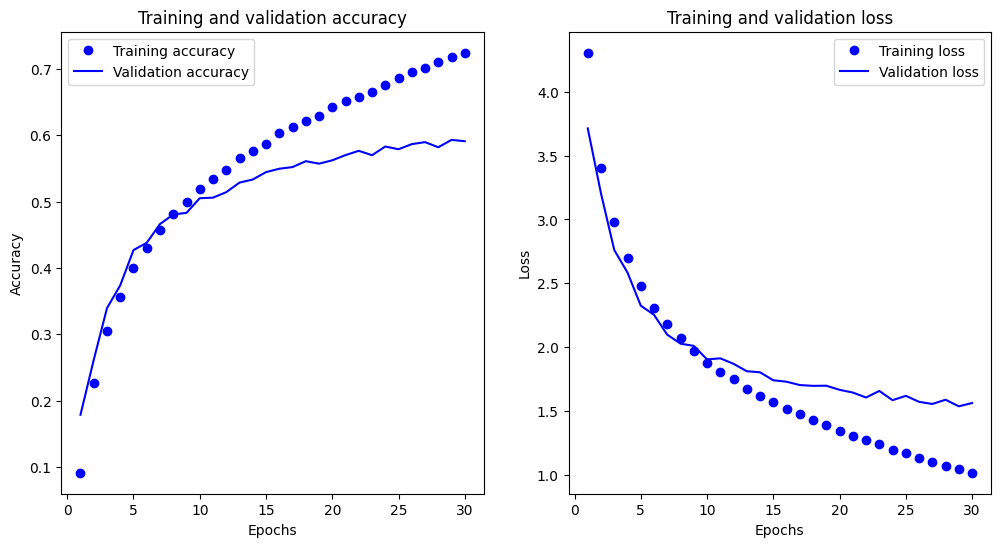

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg16 import preprocess_input, VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-100 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Split the full training set into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# One-hot encode the labels
y_train = to_categorical(y_train, 100)
y_val = to_categorical(y_val, 100)
y_test = to_categorical(y_test, 100)

# Preprocess the input data for VGG16
x_train_vgg = preprocess_input(x_train)
x_val_vgg = preprocess_input(x_val)
x_test_vgg = preprocess_input(x_test)

# Load VGG16 model without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Ensure all layers are trainable
for layer in base_model.layers:
    layer.trainable = True

# Add the dense classification layers on top of the base model
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(100, activation='softmax')
])

# Compile the model with a lower learning rate for RMSprop
model.compile(optimizer=RMSprop(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Implement early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(x_train_vgg)

# Train the model with validation data, early stopping, and data augmentation
history = model.fit(datagen.flow(x_train_vgg, y_train, batch_size=128),  # Increase batch size if possible
                    epochs=30, validation_data=(x_val_vgg, y_val), callbacks=[early_stopping])

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test_vgg, y_test)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

# Plot training history
history_dict = history.history
epochs = range(1, len(history_dict['accuracy']) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Training accuracy')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


### Results

This full trained network model achieved a higher test accuracy of 0.589 and a test loss of 1.54 which shows an increase from the previous fine tuned upperblock models.

The validation accuracy curves show a steady increase with rising epochs till the 12th epoch where it remains constant indicating some overfitting present.

The validation loss curves also demonstrate a steady decrease which levels off around the 12th epoch.

- The combination of full network training, comprehensive data augmentation, and careful optimization (low learning rate, BatchNormalization) has proven to be a successful strategy for this task.

- This full network training model shows significant improvement over previous iterations, including the fine-tuned upper block models. The higher test accuracy and lower loss indicate better generalization and overall performance. The learning curves suggest that the model learns effectively and reaches a good balance between fitting the training data and generalizing to unseen data.



### Modified Full Network Training Model

Modified Full Network Training Model for CIFAR-100 Classification

Key Differences:

1. Optimizer change from RMSprop to Adam optimizer.
   The Adam optimizer often provides faster convergence and better performance in many deep learning tasks. It adapts the learning rate for each parameter, which can be beneficial when fine-tuning a complex model like VGG16.

2. Increased learning rate from 1e-5 to 1e-4
   A slightly higher learning rate can lead to faster convergence, especially when using Adam optimizer.
3. Introduced Dropout layers (with rate 0.5) after each Dense layer   
   This dropout provides additional regularization, which can be important when training the full network to prevent overfitting. It complements BatchNormalization in regularizing the model.

4. Increased early stopping patience from 5 to 8 epochs
  A longer patience allows the model more time to potentially improve, which can be beneficial with the more complex optimization landscape of full network training.

5. Data augmentation change: slightly reduced rotation range from 25 to 20 degrees. A smaller rotation range can help maintain the integrity of important features in the small CIFAR-100 images while still providing sufficient augmentation.



169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 155ms/step - accuracy: 0.0139 - loss: 5.5653 - val_accuracy: 0.0141 - val_loss: 5.8767
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - accuracy: 0.0174 - loss: 5.0034 - val_accuracy: 0.0263 - val_loss: 4.4957
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step - accuracy: 0.0213 - loss: 4.8019 - val_accuracy: 0.0227 - val_loss: 5.1479
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - accuracy: 0.0246 - loss: 4.6873 - val_accuracy: 0.0347 - val_loss: 4.2703
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 109ms/step - accuracy: 0.0294 - loss: 4.5565 - val_accuracy: 0.0207 - val_loss: 4.9211
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - accuracy: 0.0387 - loss: 4.4268 - val_accuracy: 0.0594 - val_loss: 4.1067
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - accuracy: 0.0500 - loss: 4.2580 - val_accuracy: 0.0847 - val_loss: 3.9339
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.0541 - loss: 4.1372 - val

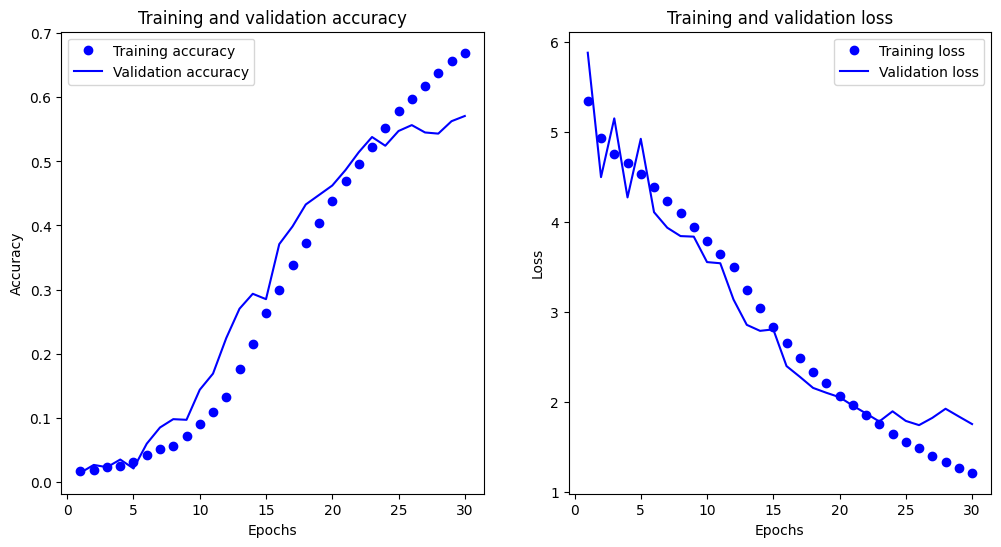

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam  # Using Adam instead of RMSprop
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg16 import preprocess_input, VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-100 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Split the full training set into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# One-hot encode the labels
y_train = to_categorical(y_train, 100)
y_val = to_categorical(y_val, 100)
y_test = to_categorical(y_test, 100)

# Preprocess the input data for VGG16
x_train_vgg = preprocess_input(x_train)
x_val_vgg = preprocess_input(x_val)
x_test_vgg = preprocess_input(x_test)

# Load VGG16 model without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Make all layers trainable for full network training
for layer in base_model.layers:
    layer.trainable = True

# Add the dense classification layers on top of the base model
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),  # Ensure dropout is included for regularization
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),  # Ensure dropout is included for regularization
    Dense(100, activation='softmax')
])

# Compile the model with Adam optimizer and a suitable learning rate
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Implement early stopping with increased patience
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# Adjusted data augmentation parameters for better training stability
datagen = ImageDataGenerator(
    rotation_range=20,  # Slightly reduced rotation range to prevent overfitting
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(x_train_vgg)

# Train the model with validation data, early stopping, and data augmentation
# Increase batch size to 128 for better gradient estimation
history = model.fit(datagen.flow(x_train_vgg, y_train, batch_size=128),
                    epochs=30, validation_data=(x_val_vgg, y_val), callbacks=[early_stopping])

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test_vgg, y_test)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

# Plot training history
history_dict = history.history
epochs = range(1, len(history_dict['accuracy']) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Training accuracy')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


### Results

This modified data augmentation model achieved a slightly lower test accuracy of 0.549 and a test loss of 1.747 which shows a decrease from the previous fully trained network model.

The training and validation accuracy curves show a steady increase over the 30 epochs. The gap between training and validation accuracy widens as training progresses, indicating some overfitting present but which is slightly less than that of the previous model.

The training loss curve decreases more rapidly and to a lower level than the validation loss, again slight indicating overfitting.

The decrease in test accuracy and increase in test loss compared to the previous model suggest that the modifications (higher learning rate, Adam optimizer, added dropout) did not improve the model's generalization ability.





## 1.2 Train own neural network

Custom CNN Model for CIFAR-100 Classification

1. Data Preparation:
   - The CIFAR-100 dataset is loaded and split into training, validation, and test sets.
   - Images are normalized by dividing pixel values by 255, scaling them to the range [0, 1] which helps in faster convergence during training.
   - Labels are one-hot encoded for multi-class classification.

2. Model Architecture:
   The model is a simple Convolutional Neural Network (CNN) with the following structure:
   - Input layer: (32, 32, 3) to match CIFAR-100 image dimensions
   - Three convolutional blocks, each consisting of:
     * Conv2D layer (increasing filters: 32, 64, 128)
     * BatchNormalization
     * MaxPooling2D
   - Flatten layer
   - Dense layer with 256 units
   - Dropout layer (0.5 rate)
   - Output Dense layer with 100 units (softmax activation)

3. Model Compilation:
   - Optimizer: Adam with learning rate 0.001
   - Loss function: Categorical crossentropy
   - Metric: Accuracy

4. Model training:
   - Batch size: 64
   - Epochs: 20 (this allows for reasonable training time while potentially reaching good performance)
  
5. Evaluation:
   The model is evaluated on the test set to assess its generalization performance.

6. Visualization:
   Training and validation accuracy/loss curves are plotted to visualize the learning process and detect potential overfitting.

This is a simple CNN Architecture which is suitable for a baseline model on a complex dataset like CIFAR-100. In the next iterations, this model will be improved.

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.0753 - loss: 4.6079 - val_accuracy: 0.1678 - val_loss: 3.5837
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2041 - loss: 3.3650 - val_accuracy: 0.2176 - val_loss: 3.3362
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2817 - loss: 2.9009 - val_accuracy: 0.3136 - val_loss: 2.7364
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3385 - loss: 2.6037 - val_accuracy: 0.3386 - val_loss: 2.6235
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3754 - loss: 2.4010 - val_accuracy: 0.3038 - val_loss: 2.8886
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4121 - loss: 2.2335 - val_accuracy: 0.3247 - val_loss: 2.6942
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4485 - loss: 2.0615 - val_accuracy: 0.3746 - val_loss: 2.4972
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4786 - loss: 1.9187 - val_accuracy: 0

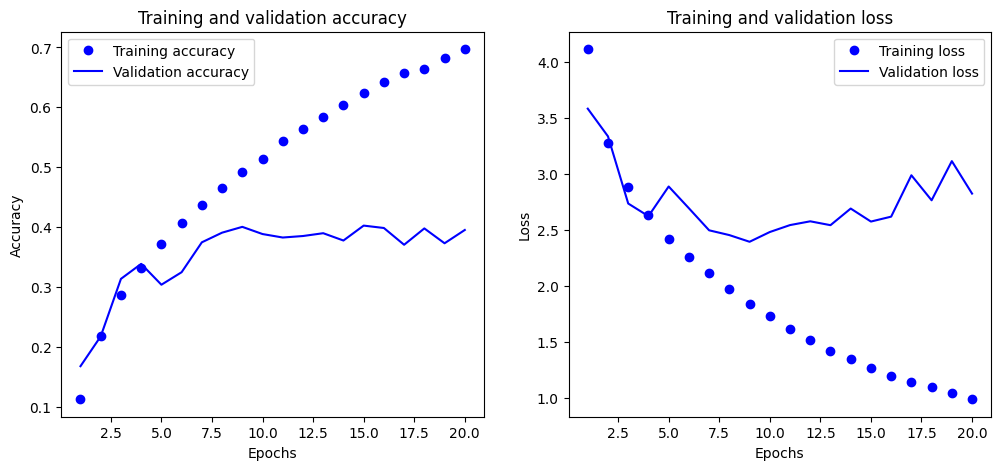

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import numpy as np

# Load CIFAR-100 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Split the full training set into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# Normalize the data
x_train, x_val, x_test = x_train / 255.0, x_val / 255.0, x_test / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, 100)
y_val = to_categorical(y_val, 100)
y_test = to_categorical(y_test, 100)

# Build a simple CNN model
model = Sequential([
    Input(shape=(32, 32, 3)),  # Define the input shape explicitly with an Input layer
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model without data augmentation
history = model.fit(x_train, y_train, batch_size=64, epochs=20, validation_data=(x_val, y_val))

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# Plotting (optional)
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], 'bo', label='Training accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], 'bo', label='Training loss')
plt.plot(epochs, history.history['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


### Results
This baseline model achieved a test accuracy of 0.396 and a test loss of 2.821. This indicates moderate performance for the CIFAR-100 dataset.

The curves show that while the training accuracy continues to increase, the validation accuracy shows signs of stagnation from the 5th epoch. This potential overfitting is also indicated by the increasing gap between training and validation accuracy.

Also, the validation loss decreases till the 5th epoch where it begins to fluctuate which further support the possibility of overfitting as training progresses.

It is observed that signs of overfitting appear as early as the 5th epoch. This suggests that the model quickly reaches its generalization capacity with the current architecture and training setup.

This baseline provides a good starting point and there is room for improvement in subsequent iterations of the model.


## Modified CNN Model



Modified CNN Model for CIFAR-100 Classification

Major adjustments:

1. Replaced standard Conv2D layers with SeparableConv2D.
     SeparableConv2D performs depthwise separable convolution, which can reduce the number of parameters and computational cost while potentially maintaining or improving performance.

2. Added 'same' padding to convolutional layers
   This padding helps maintain spatial dimensions throughout the network, potentially preserving more spatial information which can be crucial for small images like those in CIFAR-100.

3. Reduced the number of units in the final Dense layer before output from 256 to 128.This reduction in parameters can help prevent overfitting, especially when combined with other regularization techniques.

4. Data Augmentation: This expands the training set, helping to reduce overfitting and improve generalization.

5. Callbacks:
   a. Early Stopping was added with a patience of 10 epochs and best weights restoration.This prevents overfitting by stopping training when validation performance stops improving, and ensures the best performing model is saved.
   
   b. ReduceLROnPlateau was implemented to dynamically adjust the learning rate.This allows the model to adapt its learning rate, improving convergence.

6. Training Process:
   - Increased maximum epochs from 20 to 30, but with early stopping in place.
  
These modifications aim to address the overfitting observed in the baseline model while potentially improving overall performance. The changes focus on enhancing the model's ability to generalize from the limited CIFAR-100 dataset.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SeparableConv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# Load and preprocess data
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)
x_train, x_val, x_test = x_train / 255.0, x_val / 255.0, x_test / 255.0
y_train, y_val, y_test = tf.keras.utils.to_categorical(y_train, 100), tf.keras.utils.to_categorical(y_val, 100), tf.keras.utils.to_categorical(y_test, 100)

# Model definition
model = Sequential([
    Input(shape=(32, 32, 3)),
    SeparableConv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    SeparableConv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    SeparableConv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

# Train the model
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
                    epochs=30,  # Reduced number of epochs for quicker results
                    validation_data=(x_val, y_val),
                    callbacks=[early_stopping, reduce_lr])

# Evaluate and plot the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.0225 - loss: 4.5884 - val_accuracy: 0.0606 - val_loss: 4.2975 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.0475 - loss: 4.3345 - val_accuracy: 0.0930 - val_loss: 4.0263 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.0609 - loss: 4.1533 - val_accuracy: 0.1156 - val_loss: 3.8473 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.0715 - loss: 4.0591 - val_accuracy: 0.1322 - val_loss: 3.6987 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.0880 - loss: 3.9356 - val_accuracy: 0.1077 - val_loss: 3.8158 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.1024 - loss: 3.8335 - val_accuracy: 0.1589 - val_loss: 3.5020 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.1151 - l

### Accuracy plots

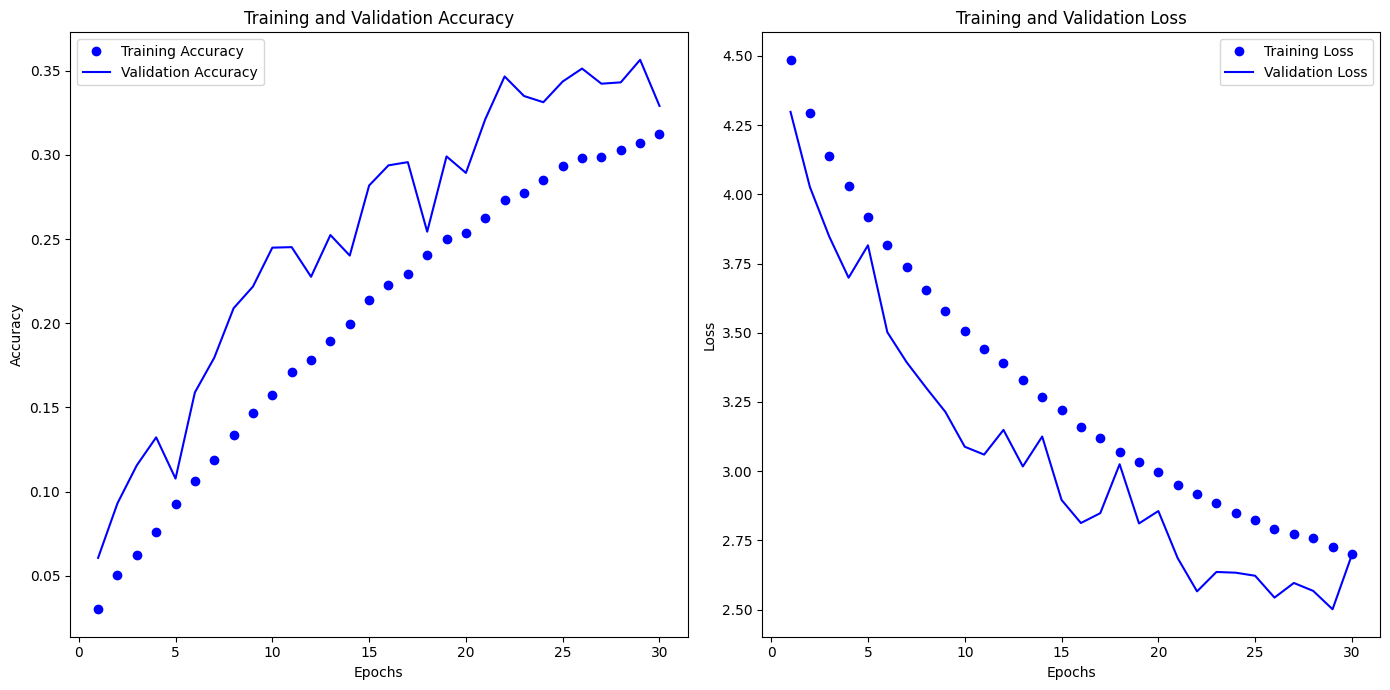

In [ ]:
import matplotlib.pyplot as plt

# Extract the history from the training session
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Create figure for plotting
plt.figure(figsize=(14, 7))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


### Results

This modification of the baseline model shows a drop in test accuracy to 0.357 and a test loss of 2.512.

The curves show that the validation accuracy increases with increase in the number of epochs, in the same direction as the training accuracy.The fluctuations on the training show signs of overfitting.

Also, the validation loss decreases all through the 30 epochs in similar direction as the training loss. There is also a overfitting observed but which is better than the previous model.

* The increase in validation accuracy alongside training accuracy throughout the 30 epochs is a positive sign, indicating that the model is learning and generalizing to some extent.
* The continued decrease in validation loss over the 30 epochs, mirroring the training loss, suggests that the model is still learning useful patterns even in later epochs.

* Although overfitting is still present, it seems to be less severe than in the previous baseline model. This suggests that the regularization techniques (data augmentation, dropout, early stopping) are having some positive effect.
  
Eventhough the modifications didn't lead to improved accuracy, they demonstrated better learning dynamics. This provides a good foundation for further refinement to achieve better performance on the CIFAR-100 dataset.

## Final modification of baseline model

Final Modified CNN Model for CIFAR-100 Classification

Major Adjustments:

1. Switched back from SeparableConv2D to standard Conv2D layers.
 They might capture more complex patterns in the CIFAR-100 dataset, potentially addressing the slight underperformance observed in the previous model.

2. Increased Network Depth:
   - Added additional convolutional layers in each block (now two Conv2D layers per block).
   Deeper networks can learn more complex features, which is beneficial for the diverse CIFAR-100 dataset. This increases the model's capacity to learn complex patterns.

3. Added L2 regularization (kernel_regularizer=l2(0.001)) to all Conv2D and Dense layers.This helps prevent overfitting by penalizing large weights, encouraging the model to learn more generalizable features.

4. Adjusted Dropout Rates:
   - Implemented a progressive dropout strategy (0.3, 0.4, 0.5) in convolutional blocks.
   - Kept 0.5 dropout for the dense layer.
   This can help in learning robust features while preventing overfitting.

5. Changed the final Dense layer before output from 128 to 256 units.
  Increasing the size of this layer provides more capacity for the model to learn complex relationships before classification, which can be beneficial for this 100-class problem.

6. Increased maximum epochs from 30 to 50
  With the enhanced regularization and deeper architecture, the model might benefit from longer training time.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# Load and preprocess data
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)
x_train, x_val, x_test = x_train / 255.0, x_val / 255.0, x_test / 255.0
y_train, y_val, y_test = tf.keras.utils.to_categorical(y_train, 100), tf.keras.utils.to_categorical(y_val, 100), tf.keras.utils.to_categorical(y_test, 100)

# Model definition
model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2, 2),
    Dropout(0.3),

    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2,2),
    Dropout(0.4),

    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

# Train the model
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
                    epochs=50,
                    validation_data=(x_val, y_val),
                    callbacks=[early_stopping, reduce_lr])

# Evaluate and plot the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")


169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.0149 - loss: 5.4386 - val_accuracy: 0.0350 - val_loss: 4.7573 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.0202 - loss: 4.8233 - val_accuracy: 0.0375 - val_loss: 4.5742 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 50ms/step - accuracy: 0.0252 - loss: 4.6579 - val_accuracy: 0.0455 - val_loss: 4.4666 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.0316 - loss: 4.5655 - val_accuracy: 0.0510 - val_loss: 4.4929 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.0412 - loss: 4.4783 - val_accuracy: 0.0618 - val_loss: 4.2746 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.0499 - loss: 4.4230 - val_accuracy: 0.0751 - val_loss: 4.3041 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.0619 - loss: 4.3844

### Results

This final modification of the baseline model shows an increase in test accuracy to 0.443 and a test loss of 2.345.

The test accuracy of 0.443 and test loss of 2.345 show a significant improvement over both the original baseline model (0.396 accuracy, 2.821 loss) and the previous modified model (0.357 accuracy, 2.512 loss). This is a positive outcome, indicating that the latest modifications were effective.

Reasons for Improvement:
   * Increased Model Capacity: The deeper network with additional convolutional layers likely allowed the model to learn more complex features, which is important for the diverse CIFAR-100 dataset.
   
   * Balanced Regularization: The combination of L2 regularization, progressive dropout, and data augmentation seems to have struck a good balance between preventing overfitting and allowing the model to learn effectively.
   
   * Extended Training: The increased maximum epochs to 50 may have allowed the model to continue learning and improving for a longer period.

Overall, this final modified baseline model represents a significant step forward in the CIFAR-100 classification task.